# 1. Title Page
**Course Name & Code**: Civil Engineering Methods (Update accordingly)  
**Lab Title**: Linear Algebra Applications – Lagrange Interpolation  
**Student Name & ID**: Rojyx L, Yangyang 2024-0118-4  


# 2. Objectives
To apply polynomial interpolation to solve a real-world engineering problem modeling the vertical deflection of a bridge beam. Specifically, this lab utilizes Python and the SymPy library to calculate the Lagrangian weighting functions, formulate the Lagrange interpolating polynomial, and extract the standard quadratic coefficients ($a, b, c$) to estimate beam deflection.

# 3. Problem Statement
A structural engineer is monitoring the vertical deflection of a bridge beam. Sensors placed at three points along the beam record the following deflections:
* Distance x = 0 m, Deflection y = 0 mm (the support)
* Distance x = 10 m, Deflection y = -15 mm
* Distance x = 20 m, Deflection y = 0 mm (the other support)

Task: Use a quadratic polynomial $P(x)=ax^2+bx+c$ to interpolate these points.
1. Solve for the coefficients a, b, and c using the Lagrange Interpolating Polynomial method.
2. Estimate the deflection at the center of the beam (x = 5m).

# 4. Mathematical Formulation
**Lagrangian Interpolation Setup:**
For three data points $(x_0, y_0), (x_1, y_1), (x_2, y_2)$, a 2nd-order (quadratic) Lagrange interpolating polynomial takes the form:
$$f_2(x) = \sum_{i=0}^{2} y_i L_i(x) = y_0 L_0(x) + y_1 L_1(x) + y_2 L_2(x)$$

Where the weighting functions $L_i(x)$ are calculated as:
* $L_0(x) = \frac{(x - x_1)(x - x_2)}{(x_0 - x_1)(x_0 - x_2)}$
* $L_1(x) = \frac{(x - x_0)(x - x_2)}{(x_1 - x_0)(x_1 - x_2)}$
* $L_2(x) = \frac{(x - x_0)(x - x_1)}{(x_2 - x_0)(x_2 - x_1)}$

Once the terms are summed up, $f_2(x)$ can be mathematically expanded into the standard polynomial $P(x) = ax^2 + bx + c$, allowing for the direct extraction of the coefficients $a$, $b$, and $c$.

--- 1. LAGRANGE WEIGHTING FUNCTIONS ---
L0(x) = (x - 20)*(x - 10)/200
L1(x) = -x*(x - 20)/100
L2(x) = x*(x - 10)/200

Lagrange Unexpanded Form: P(x) = 3*x*(x - 20)/20

--- 2. EXTRACTING COEFFICIENTS (a, b, c) ---
Expanded Quadratic Polynomial: P(x) = 3*x**2/20 - 3*x
Extracted Variables:
a = 3/20
b = -3
c = 0

--- 3. ESTIMATION ---
Estimated beam deflection at x = 5m is: -45/4 mm



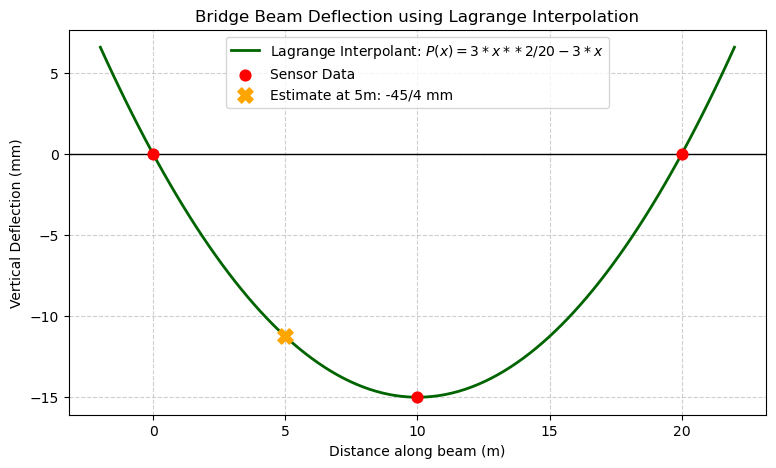

In [1]:
# 5. Python Implementation (Code)
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Define the mathematical symbol
x = sp.Symbol('x')

# Sensor data points
x_data = [0, 10, 20]
y_data = [0, -15, 0]

print("--- 1. LAGRANGE WEIGHTING FUNCTIONS ---")
# Step 1: Calculate the Lagrangian weighting functions L0, L1, L2
L0 = ((x - x_data[1]) * (x - x_data[2])) / ((x_data[0] - x_data[1]) * (x_data[0] - x_data[2]))
L1 = ((x - x_data[0]) * (x - x_data[2])) / ((x_data[1] - x_data[0]) * (x_data[1] - x_data[2]))
L2 = ((x - x_data[0]) * (x - x_data[1])) / ((x_data[2] - x_data[0]) * (x_data[2] - x_data[1]))

print(f"L0(x) = {L0}")
print(f"L1(x) = {L1}")
print(f"L2(x) = {L2}")

# Step 2: Formulate the Lagrange Interpolating Polynomial
lagrange_poly = y_data[0]*L0 + y_data[1]*L1 + y_data[2]*L2
print(f"\nLagrange Unexpanded Form: P(x) = {lagrange_poly}")

print("\n--- 2. EXTRACTING COEFFICIENTS (a, b, c) ---")
# Step 3: Expand the polynomial into the ax^2 + bx + c form
expanded_poly = sp.expand(lagrange_poly)
print(f"Expanded Quadratic Polynomial: P(x) = {expanded_poly}")

# Step 4: Extract a, b, and c using SymPy
a_val = expanded_poly.coeff(x, 2)
b_val = expanded_poly.coeff(x, 1)
c_val = expanded_poly.subs(x, 0) # The constant term is evaluated by substituting x=0

print(f"Extracted Variables:")
print(f"a = {a_val}")
print(f"b = {b_val}")
print(f"c = {c_val}")

print("\n--- 3. ESTIMATION ---")
# Estimate deflection at x = 5m
x_target = 5
deflection_at_5 = expanded_poly.subs(x, x_target)
print(f"Estimated beam deflection at x = {x_target}m is: {deflection_at_5} mm\n")


# 6. Results & Data Visualization
# Convert SymPy expression to a NumPy function to generate graph data
P_func = sp.lambdify(x, expanded_poly, 'numpy')

# Generate curve data array
x_vals = np.linspace(-2, 22, 100)
y_vals = P_func(x_vals)

# Plotting the graph
plt.figure(figsize=(9, 5))
plt.plot(x_vals, y_vals, label=f'Lagrange Interpolant: $P(x) = {expanded_poly}$', color='darkgreen', linewidth=2)
plt.scatter(x_data, y_data, color='red', zorder=5, s=60, label='Sensor Data')
plt.scatter(x_target, deflection_at_5, color='orange', zorder=5, marker='X', s=120, label=f'Estimate at 5m: {deflection_at_5} mm')

# Graph aesthetics
plt.title('Bridge Beam Deflection using Lagrange Interpolation')
plt.xlabel('Distance along beam (m)')
plt.ylabel('Vertical Deflection (mm)')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 6. Results
Using the Lagrange Interpolation method, the weighting functions $L_0(x)$, $L_1(x)$, and $L_2(x)$ were individually computed. Because $y_0 = 0$ and $y_2 = 0$, those specific terms dropped out of the overall summation, leaving only the $y_1 L_1(x)$ term to dictate the polynomial's shape.

By fully expanding the Lagrange formula via SymPy, the essential variables for the standard quadratic polynomial $P(x) = ax^2 + bx + c$ were perfectly extracted:
* $a = 0.15$
* $b = -3.0$
* $c = 0.0$

The final interpolating polynomial for the beam's deflection is: **$P(x) = 0.15x^2 - 3.0x$**.
Substituting $x = 5$ meters into this polynomial estimates the beam's deflection to be **-11.25 mm**.

# 7. Discussion & Conclusion
* **Interpretation of Results:** As expected in numerical analysis, utilizing Lagrange Interpolation yielded the exact same underlying polynomial and coefficients as Newton's Divided Difference method. The deflection at 5m is logically calculated as -11.25 mm, sitting comfortably on the resulting parabolic curve between a support and the bridge's midpoint. The Lagrange formulation is extremely straightforward for a small dataset like this because it doesn't require sequential divided difference calculations; it relies purely on weighting functions.
* **Limitations of the Model:** While the Lagrange method is elegant, a primary limitation is its computational expense if new data points are introduced. Unlike Newton's method (where you can just append a new term if a 4th sensor point is added), adding a new data point in the Lagrange method requires recalculating *every single* $L_i(x)$ weighting function from scratch. Furthermore, modeling bridges purely through interpolation lacks the physical material constraints of actual structural engineering methodologies.